In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../data/ridership_headline.parquet"

df = pd.read_parquet(DATA_PATH)

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by='date').set_index('date')

print(df.shape)
print(df.head())
print(df.describe())
print(df.dtypes)

(2738, 14)
            bus_rkl  bus_rkn  bus_rpn  rail_lrt_ampang  rail_mrt_kajang  \
date                                                                      
2019-01-01     <NA>     <NA>     <NA>           113357           114173   
2019-01-02     <NA>     <NA>     <NA>           182715           169316   
2019-01-03     <NA>     <NA>     <NA>           187904           175304   
2019-01-04     <NA>     <NA>     <NA>           198420           187891   
2019-01-05     <NA>     <NA>     <NA>           120773           112660   

            rail_lrt_kj  rail_monorail  rail_mrt_pjy  rail_lrt_shah_alam  \
date                                                                       
2019-01-01       139634          35804          <NA>                <NA>   
2019-01-02       274224          31859          <NA>                <NA>   
2019-01-03       286469          31893          <NA>                <NA>   
2019-01-04       304755          34121          <NA>                <NA>   
2019-01

In [4]:
expected_date = pd.date_range(df.index.min(), df.index.max(), freq='D')

missing_dates = expected_date.difference(df.index)

print(f"Missing dates: {len(missing_dates)}")

Missing dates: 0


In [7]:
quality = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': df.isna().mean().mul(100),
    'zero_count': (df == 0).sum(),
    'zero_valid': df.apply(pd.Series.first_valid_index),
    'last_valid': df.apply(pd.Series.last_valid_index),
})

display(quality.sort_values('missing_pct', ascending=False))


,missing_count,missing_pct,zero_count,zero_valid,last_valid
rail_lrt_shah_alam,2678,97.808619,58,2026-04-01,2026-06-30
rail_komuter,1713,62.563915,0,2023-09-10,2026-06-30
rail_tebrau,1265,46.201607,0,2022-06-19,2026-06-30
rail_mrt_pjy,1262,46.092038,0,2022-06-16,2026-06-30
bus_rkl,1096,40.029218,0,2022-01-01,2026-06-30
bus_rkn,1096,40.029218,198,2022-01-01,2026-06-30
bus_rpn,1096,40.029218,0,2022-01-01,2026-06-30
rail_komuter_utara,653,23.849525,0,2020-10-15,2026-06-30
rail_intercity,653,23.849525,0,2020-10-15,2026-06-30
rail_ets,653,23.849525,0,2020-10-15,2026-06-30


[Text(0.5, 1.0, 'Daily Ridership of MRT Kajang'),
 Text(0.5, 0, 'Date'),
 Text(0, 0.5, 'Ridership Count')]

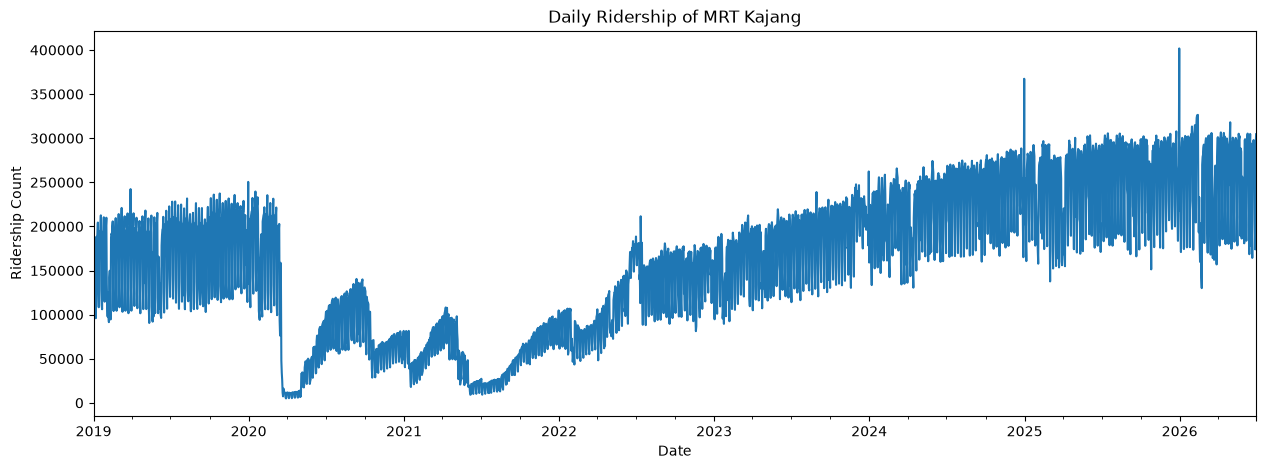

In [8]:
target = 'rail_mrt_kajang'

fig, ax = plt.subplots(figsize=(15, 5))
df[target].plot(ax=ax)

ax.set(
    title="Daily Ridership of MRT Kajang",
    xlabel="Date",
    ylabel="Ridership Count"
)

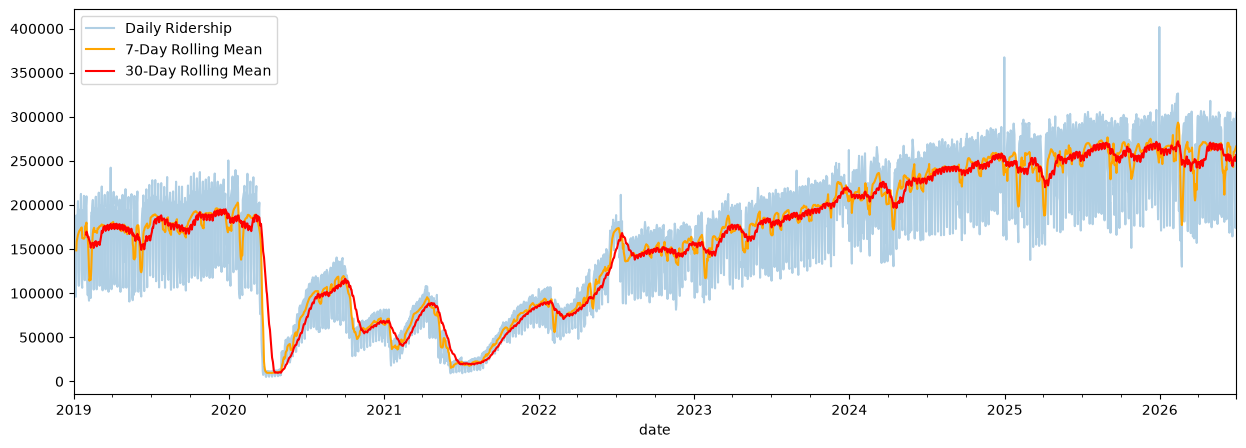

In [9]:
ax = df[target].plot(figsize=(15, 5), alpha=0.35, label='Daily Ridership')
df[target].rolling(7).mean().plot(ax=ax, label='7-Day Rolling Mean', color='orange')
df[target].rolling(30).mean().plot(ax=ax, label='30-Day Rolling Mean', color='red')

ax.legend()
plt.show()